# Library + Data imports

In [3]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
from manual_dt import ManualDecisionTree
from manual_dt import Node

In [ ]:
df_train = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/train-00000-of-00001.parquet')
df_val = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/validation-00000-of-00001.parquet')
df_test = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/test-00000-of-00001.parquet')
df_raw = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/raw-emo/train-00000-of-00001.parquet')

In [5]:
# df_train = pd.read_parquet('./simplified/train-00000-of-00001.parquet')
# df_val = pd.read_parquet('./simplified/validation-00000-of-00001.parquet')
# df_test = pd.read_parquet('./simplified/test-00000-of-00001.parquet')
# df_raw = pd.read_parquet('./raw/test-00000-of-00001.parquet')

# Acquiring labels (in raw dataset)

In [6]:
non_labels = [
    "text",
    "id",
    "author",
    "subreddit",
    "link_id",
    "parent_id",
    "created_utc",
    "rater_id",
    "example_very_unclear"
]

label_columns = [col for col in df_raw.columns if col not in non_labels]

In [7]:
label_columns

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

In [8]:
label_eda = label_columns.copy()[:27]
label_eda

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise']

# Missing Values + First Look

In [9]:
df_train.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [10]:
df_train.shape

(43410, 3)

In [11]:
df_train.isnull().sum()

text      0
labels    0
id        0
dtype: int64

In [12]:
df_train["labels"].value_counts()

labels
[27]        12823
[0]          2710
[4]          1873
[15]         1857
[1]          1652
            ...  
[14, 27]        1
[14, 27]        1
[2, 3]          1
[1, 24]         1
[9, 27]         1
Name: count, Length: 7130, dtype: int64

In [13]:
train_texts = set(df_train["text"])
test_texts = set(df_test["text"])

overlap = train_texts.intersection(test_texts)
print(len(overlap))

print(overlap)

32
{'Weird flex but ok', 'Good luck!', 'That’s awesome!', 'Thank you!', 'thank you!!', 'I like it', 'I love it', 'My condolences.', 'This is amazing', 'Love your username', 'How old are you?', 'I agree with this', 'Happy birthday!', 'Go on...', 'Thank you :)', 'What a legend', 'Thank you for your service', 'I miss [NAME]', 'And then everyone clapped', '[NAME].', 'Thanks I hate it.', 'Thank you.', 'How do you know this?', 'Happy cake day!', 'Thank you. [NAME]', 'This is terrifying', 'Omg I love it', 'You’re welcome', 'Weird flex, but ok', 'Bless you.', 'Is that [NAME]?', 'It really do be like that'}


# Exploratory Data Analysis

In [14]:
label_counts = np.zeros(len(label_eda), dtype = int)
for labels in df_train["labels"]:
    if 27 in labels: # neutral
        continue
    for label in labels:
        label_counts[label] += 1

label_df = pd.DataFrame({"Emotion": label_eda, "Count": label_counts})
label_df = label_df.sort_values(by="Count", ascending=False)

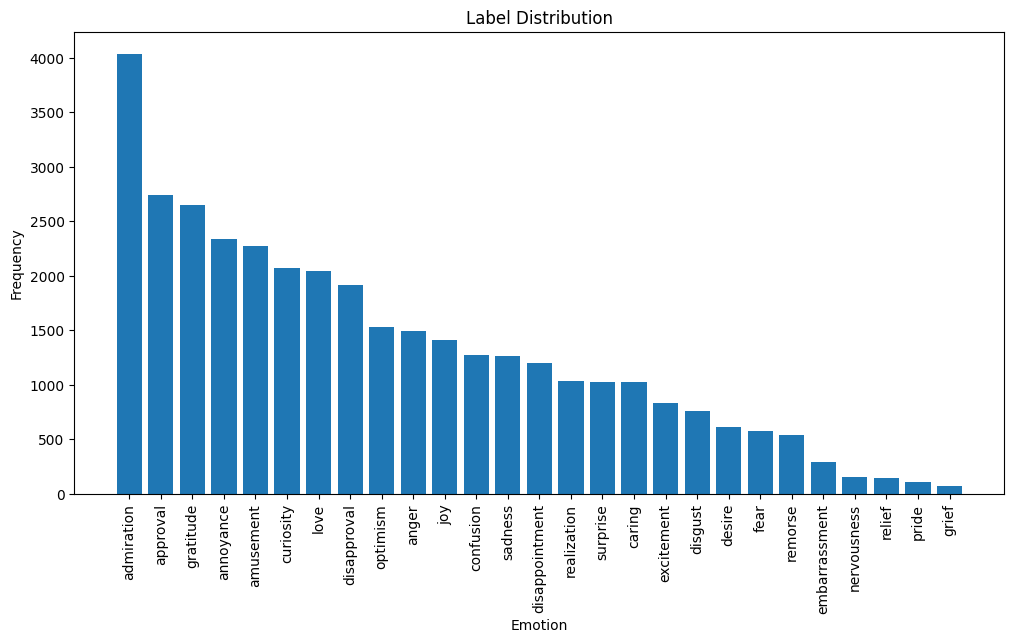

In [15]:
plt.figure(figsize=(12,6))
plt.bar(label_df["Emotion"], label_df["Count"])
plt.xticks(rotation=90)

plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.title("Label Distribution")

plt.show()

# Preprocessing

Label Pre-processing

In [16]:
df_train['single_label'] = df_train['labels'].apply(lambda x: x[0])

Text Pre-processing (Tokenize, Vectorize)

In [17]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
def text_split(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return words

df_train["tokens"] = df_train["text"].apply(text_split)

In [19]:
counter = Counter()
max_vocab = 10000

# Bag of Words (BoW)
vocab = {}

for t in df_train["tokens"]:
    counter.update(t)
    

for i, (word, freq) in enumerate(counter.most_common(max_vocab)):
    vocab[word] = i

In [20]:
def vectorize(tokens, vocab):
    vec = np.zeros(len(vocab), dtype=np.uint8)
    
    for w in tokens:
        if w in vocab:
            vec[vocab[w]] = 1
            
    return vec

In [21]:
X = np.array([vectorize(tokens, vocab) for tokens in df_train["tokens"]])
y = df_train['single_label'].values

In [22]:
X.shape

(43410, 10000)

Validation Pre-processing

In [23]:
df_val["single_label"] = df_val["labels"].apply(lambda x: x[0])

In [24]:
df_val["tokens"] = df_val["text"].apply(text_split)
X_val = np.array([vectorize(tokens, vocab) for tokens in df_val["tokens"]])
y_val = df_val["single_label"].values

Test Pre-processing

In [25]:
df_test["tokens"] = df_test["text"].apply(text_split)
X_test = np.array([vectorize(tokens, vocab) for tokens in df_test["tokens"]])
y_test = df_test["labels"]

# Adjustment Functions

In [26]:
def relaxed_adjust(true_label, pred_label):
    adjusted_true = []
    for true_labels, pred in zip(true_label, pred_label):
        if pred in true_labels:
            adjusted_true.append(pred)
        else:
            adjusted_true.append(true_labels[0])
    return np.array(adjusted_true)

In [27]:
def binary_labels(y):
    binary = []
    for labels in y:
        multi_hot = [0]*(len(label_columns))
        if isinstance(labels, (int, np.integer)):
            multi_hot[labels] = 1
        else:
            for label in labels:
                multi_hot[label] = 1
        binary.append(multi_hot)
    return np.array(binary)

In [28]:
def results_display(true_labels, predicted_labels):
    adj_true = relaxed_adjust(true_labels, predicted_labels)
    true_bin = binary_labels(true_labels)
    pred_bin = binary_labels(predicted_labels)

    acc = np.mean(adj_true == predicted_labels)
    print(f"Relaxed Accuracy: {acc}")

    relaxed_f1 = f1_score(adj_true, predicted_labels, average="macro")
    print(f"Relaxed F1 Score: {relaxed_f1}")

    org_f1 = f1_score(true_bin, pred_bin, average="macro")
    print(f"F1 Score: {org_f1}")

    print(classification_report(adj_true, predicted_labels, zero_division = 0, target_names = label_columns, labels=np.arange(len(label_columns))))
    
    mcm = multilabel_confusion_matrix(true_bin, pred_bin)
    mcm_list = [1, 2, 18, 25, 27] # amusement, anger, love, sadness, neutral
    for i in mcm_list:
        disp = ConfusionMatrixDisplay(confusion_matrix=mcm[i])
        disp.plot(cmap="Blues")
        plt.title(label_columns[i])
        plt.show()

    return {"Relaxed Accuracy": acc, "Relaxed Macro F1": relaxed_f1, "Multilabel Macro F1": org_f1}

# Decision Tree - Gini (manual)

Build and Validate Tree

In [29]:
# Validate using F1-Score
depths = [3,4,5,8,10,15,20,25,30]

best_depth = 0
best_f1 = 0

# Manual trees takes forever to fit 40k ish train data, so take a chunk (1000/43k)
X_small = X[:1000]
y_small = y[:1000]

for d in depths:
    print(f"Building tree with depth {d}")
    tree = ManualDecisionTree(max_depth = d, min_sample_split=5)
    tree.fit(X_small, y_small)
    y_pred_val = tree.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_depth = d
    print(f"F1 score: {f1}")
print("Best depth: ", best_depth)

Building tree with depth 3
F1 score: 0.0654536929837874
Building tree with depth 4
F1 score: 0.08798586018778039
Building tree with depth 5
F1 score: 0.1046921741792436
Building tree with depth 8
F1 score: 0.12335867467264881
Building tree with depth 10
F1 score: 0.13124777860712203
Building tree with depth 15
F1 score: 0.16620309943912007
Building tree with depth 20
F1 score: 0.16138644348481807
Building tree with depth 25
F1 score: 0.17028195558038545
Building tree with depth 30
F1 score: 0.17672038739170692
Best depth:  30


Rebuild and test 

In [30]:
best_man_DT = ManualDecisionTree(max_depth=best_depth)
best_man_DT.fit(X_small, y_small)
y_pred_test = best_man_DT.predict(X_test)

Results

Relaxed Accuracy: 0.47282107978625393
Relaxed F1 Score: 0.20612378468685993
F1 Score: 0.18475203473139903
                precision    recall  f1-score   support

    admiration       0.40      0.30      0.34       449
     amusement       0.76      0.67      0.71       249
         anger       0.45      0.24      0.31       187
     annoyance       0.09      0.02      0.03       261
      approval       0.24      0.07      0.11       286
        caring       0.14      0.02      0.03       106
     confusion       0.00      0.00      0.00       128
     curiosity       0.45      0.02      0.05       208
        desire       0.00      0.00      0.00        68
disappointment       0.09      0.01      0.02       114
   disapproval       0.18      0.04      0.06       209
       disgust       0.17      0.02      0.04        83
 embarrassment       0.00      0.00      0.00        27
    excitement       0.77      0.23      0.35        75
          fear       0.33      0.01      0.03        

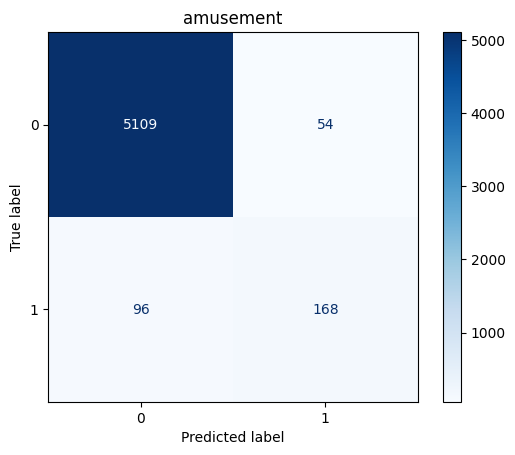

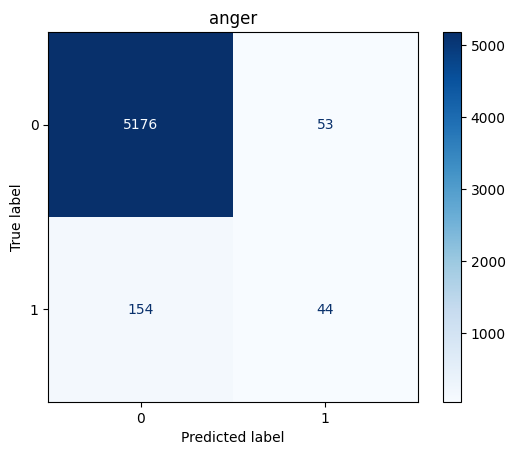

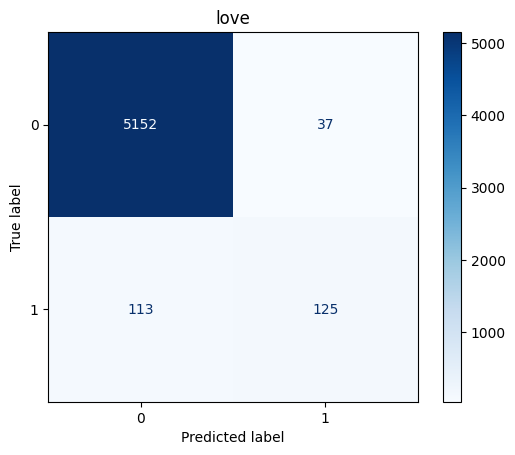

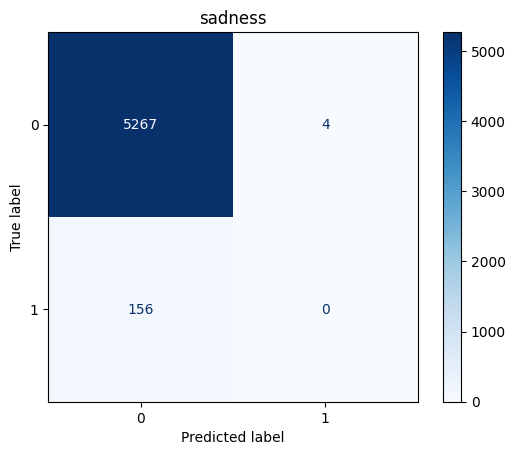

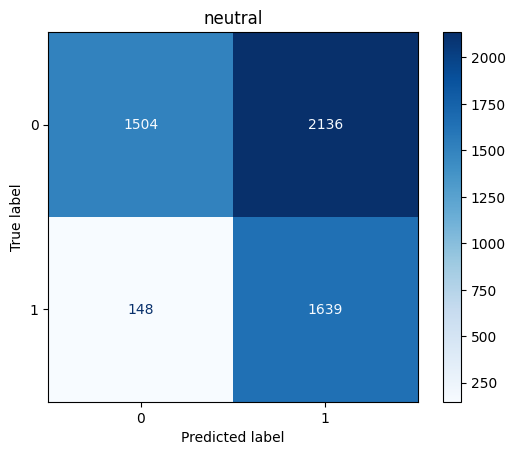

In [31]:
DT_manual_metrics = results_display(y_test, y_pred_test)

# Decision Tree - Gini (Sklearn)

Fit and Validate

In [32]:
best_f1 = -1
best_depth = 0

for depth in range(5,27,3):
    print(f"Training with depth {depth}")
    tree = DecisionTreeClassifier(criterion="gini", max_depth=depth, random_state=42)
    tree.fit(X, y)
    y_pred_val = tree.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_depth = depth
    print(f"F1 score: {f1}")
print("Best depth: ", best_depth)

Training with depth 5
F1 score: 0.09976108618149858
Training with depth 8
F1 score: 0.14251570689282095
Training with depth 11
F1 score: 0.15366237527864654
Training with depth 14
F1 score: 0.18603895031993695
Training with depth 17
F1 score: 0.20413701265384707
Training with depth 20
F1 score: 0.21854862475614453
Training with depth 23
F1 score: 0.22939905249394518
Training with depth 26
F1 score: 0.24403102794650305
Best depth:  26


Final build and test

In [33]:
best_sk_DT = DecisionTreeClassifier(criterion="gini", max_depth=best_depth, random_state=42)
best_sk_DT.fit(X,y)
y_pred_test = best_sk_DT.predict(X_test)

Results

Relaxed Accuracy: 0.5129906025428413
Relaxed F1 Score: 0.25589166064359775
F1 Score: 0.2262922457470485
                precision    recall  f1-score   support

    admiration       0.61      0.47      0.53       463
     amusement       0.76      0.68      0.72       246
         anger       0.50      0.22      0.31       186
     annoyance       0.00      0.00      0.00       258
      approval       0.53      0.08      0.15       283
        caring       0.17      0.02      0.03       103
     confusion       0.00      0.00      0.00       127
     curiosity       0.60      0.03      0.06       203
        desire       0.56      0.21      0.31        70
disappointment       0.00      0.00      0.00       112
   disapproval       0.50      0.01      0.02       208
       disgust       0.94      0.20      0.33        85
 embarrassment       0.00      0.00      0.00        27
    excitement       0.42      0.07      0.12        72
          fear       0.00      0.00      0.00        70

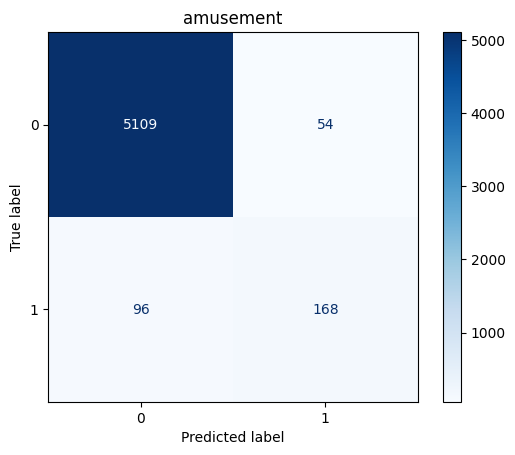

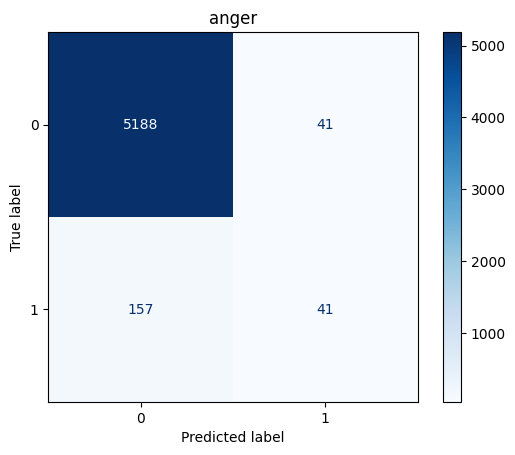

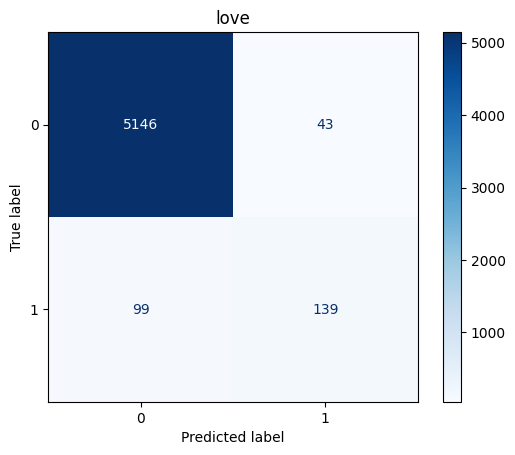

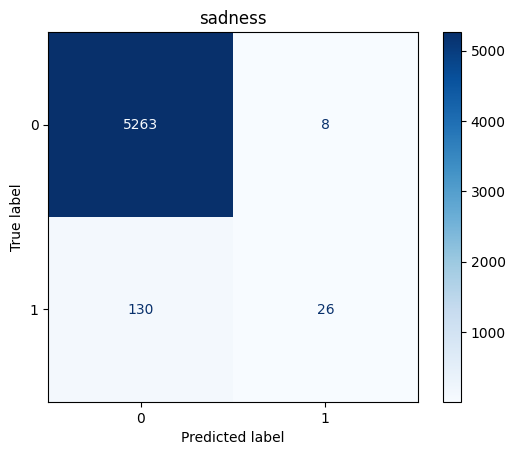

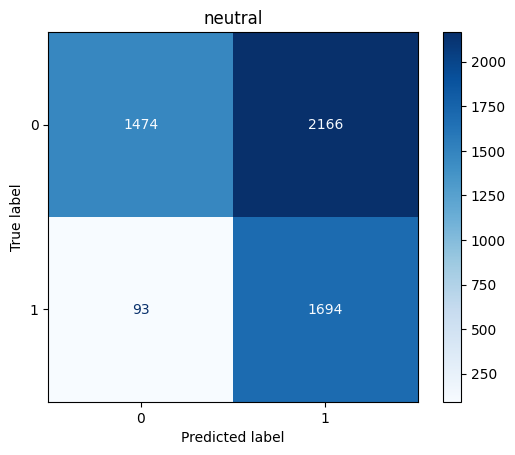

In [34]:
DT_sklearn_metrics = results_display(y_test, y_pred_test)

# Logistic Regression (Sklearn)

Fit and Validate

In [35]:
best_c = None
best_f1 = -1

for c in [0.01, 0.05, 0.1, 0.5, 1, 5, 10]:
    print(f"Training with C = {c}")
    model = LogisticRegression(C=c,max_iter=1000)
    model.fit(X, y)
    y_pred_val = model.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_c = c
    print(f"F1 score: {f1}")
print("Best c: ", best_c)

Training with C = 0.01
F1 score: 0.1403282374277032
Training with C = 0.05
F1 score: 0.2649279116296475
Training with C = 0.1
F1 score: 0.29999540833401317
Training with C = 0.5
F1 score: 0.3527470625543809
Training with C = 1
F1 score: 0.3684505549632958
Training with C = 5
F1 score: 0.3435087141809431
Training with C = 10
F1 score: 0.3278231105366704
Best c:  1


Predict on test data

In [36]:
best_LR = LogisticRegression(C=best_c, max_iter=1000)
best_LR.fit(X, y)
y_pred_test = best_LR.predict(X_test)

Results

Relaxed Accuracy: 0.5616362631288004
Relaxed F1 Score: 0.3935633877480999
F1 Score: 0.34777943511512194
                precision    recall  f1-score   support

    admiration       0.59      0.65      0.62       454
     amusement       0.76      0.81      0.78       252
         anger       0.48      0.40      0.43       179
     annoyance       0.35      0.21      0.26       266
      approval       0.36      0.24      0.29       291
        caring       0.31      0.19      0.23       107
     confusion       0.33      0.15      0.21       125
     curiosity       0.36      0.10      0.16       205
        desire       0.54      0.29      0.38        66
disappointment       0.40      0.17      0.23       115
   disapproval       0.22      0.10      0.14       212
       disgust       0.64      0.41      0.50        86
 embarrassment       0.45      0.19      0.27        26
    excitement       0.48      0.37      0.42        71
          fear       0.75      0.59      0.66        73

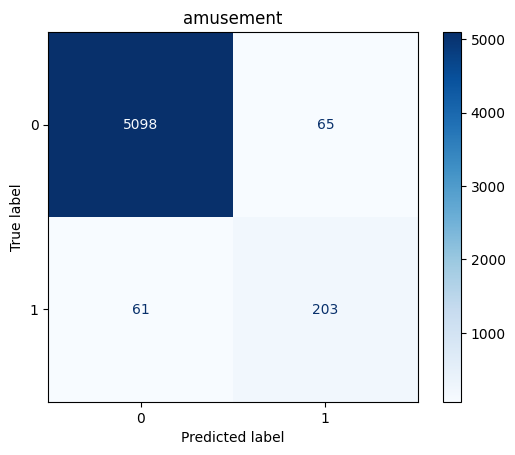

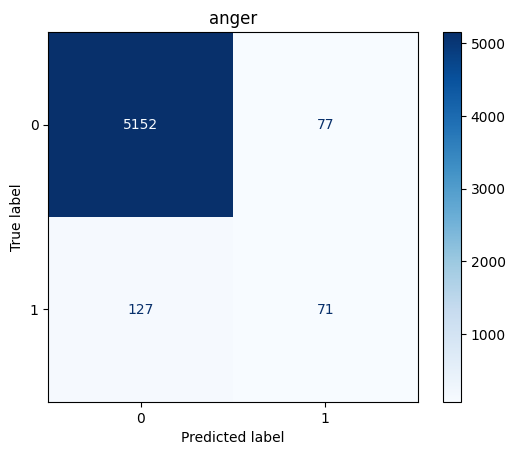

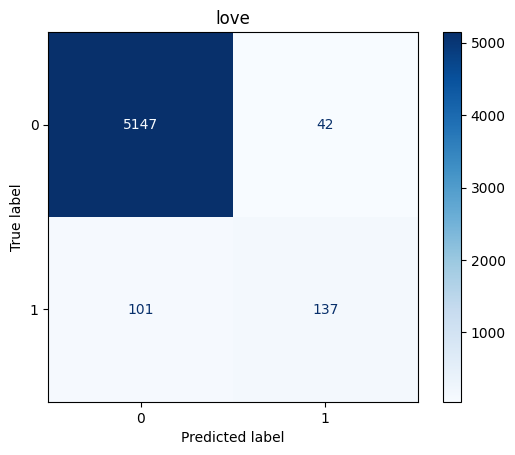

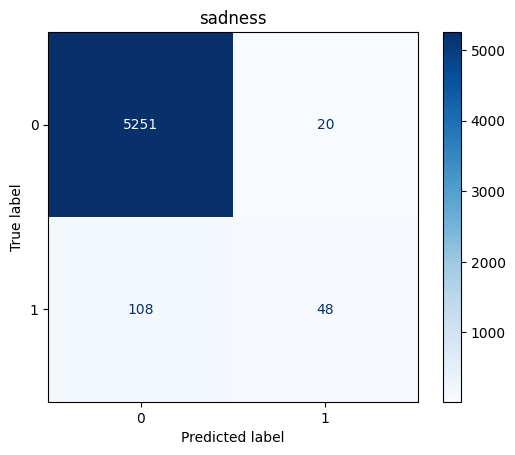

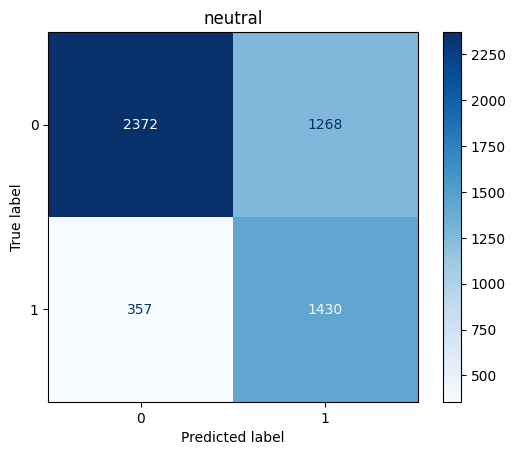

In [37]:
LR_sklearn_metrics = results_display(y_test, y_pred_test)

# Naive Bayes - Bernoulli (Sklearn)

Fit and Validate

In [38]:
best_alpha = None
best_f1 = -1

for alpha in [0.1, 0.5, 1.0, 2.0]:
    print(f"Training model with alpha = {alpha}")
    model = BernoulliNB(alpha=alpha)
    model.fit(X, y)
    y_pred_val = model.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average="macro")
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha
    print(f"F1 score: {f1}")
print("Best alpha: ", best_alpha)

Training model with alpha = 0.1
F1 score: 0.25444257499345957
Training model with alpha = 0.5
F1 score: 0.18120535182186945
Training model with alpha = 1.0
F1 score: 0.10792562031676026
Training model with alpha = 2.0
F1 score: 0.0505814290895278
Best alpha:  0.1


Predict on test data

In [39]:
best_Ber = BernoulliNB(alpha=best_alpha)
best_Ber.fit(X, y)
y_pred_test = best_Ber.predict(X_test)

Results

Relaxed Accuracy: 0.45973834531048463
Relaxed F1 Score: 0.27958325380129107
F1 Score: 0.24904582088834612
                precision    recall  f1-score   support

    admiration       0.47      0.58      0.52       464
     amusement       0.62      0.56      0.59       243
         anger       0.35      0.26      0.30       176
     annoyance       0.27      0.21      0.23       274
      approval       0.26      0.19      0.22       287
        caring       0.20      0.22      0.21       110
     confusion       0.18      0.11      0.14       124
     curiosity       0.19      0.12      0.14       208
        desire       0.32      0.10      0.15        69
disappointment       0.26      0.15      0.19       124
   disapproval       0.19      0.12      0.15       218
       disgust       0.37      0.25      0.30        85
 embarrassment       0.00      0.00      0.00        29
    excitement       0.22      0.20      0.21        75
          fear       0.61      0.26      0.37        

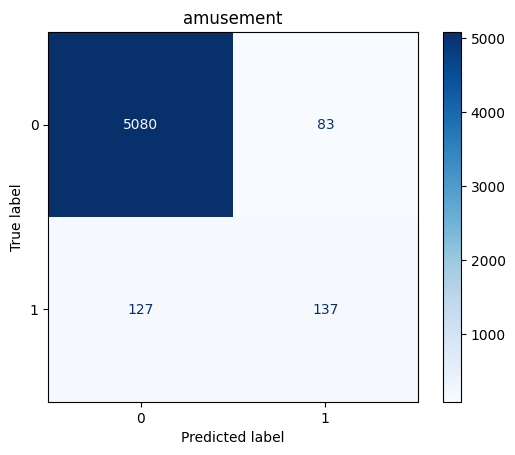

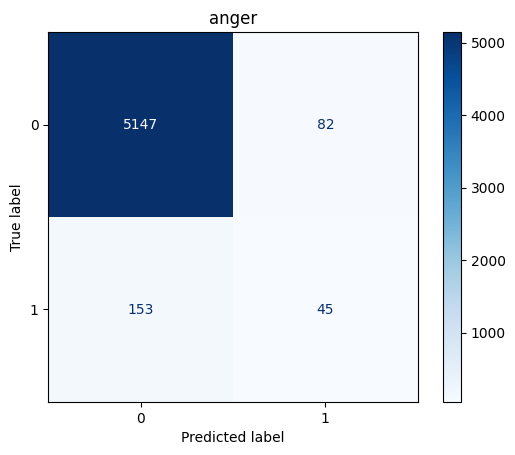

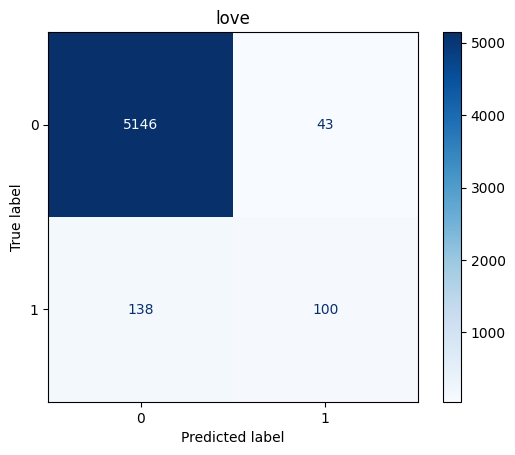

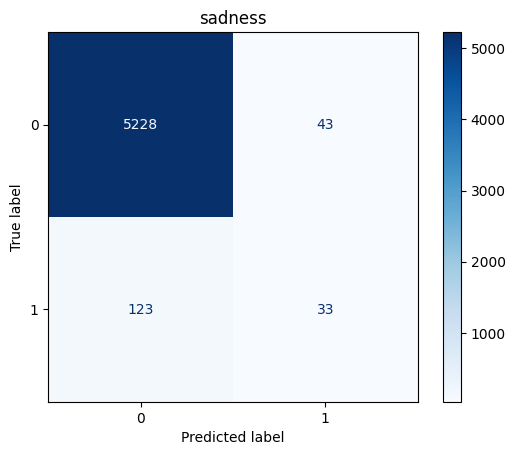

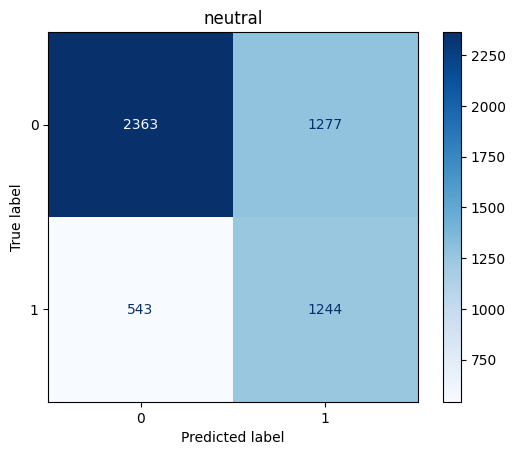

In [40]:
BerNB_sklearn_metrics = results_display(y_test, y_pred_test)

# Naive Bayes - Binomial (Sklearn)

Fit and Validate

In [41]:
best_alpha = None
best_f1 = -1

for alpha in [0.1, 0.5, 1.0, 2.0]:
    print(f"Training model with alpha = {alpha}")
    model = MultinomialNB(alpha=alpha)
    model.fit(X, y)
    y_pred_val = model.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha
    print(f"F1 score: {f1}")
print("Best alpha: ", best_alpha)

Training model with alpha = 0.1
F1 score: 0.2679853070957233
Training model with alpha = 0.5
F1 score: 0.2525002054741068
Training model with alpha = 1.0
F1 score: 0.21959288806841779
Training model with alpha = 2.0
F1 score: 0.16164937461446136
Best alpha:  0.1


Predict on test data

In [42]:
best_Mul = MultinomialNB(alpha=best_alpha)
best_Mul.fit(X, y)
y_pred_test = best_Mul.predict(X_test)

Results

Relaxed Accuracy: 0.46121245623733187
Relaxed F1 Score: 0.31036531084501057
F1 Score: 0.2734968920516298
                precision    recall  f1-score   support

    admiration       0.48      0.58      0.52       466
     amusement       0.59      0.57      0.58       242
         anger       0.33      0.25      0.28       176
     annoyance       0.29      0.22      0.25       275
      approval       0.26      0.19      0.22       288
        caring       0.26      0.29      0.28       112
     confusion       0.23      0.13      0.17       126
     curiosity       0.23      0.13      0.17       210
        desire       0.32      0.14      0.20        69
disappointment       0.28      0.16      0.21       122
   disapproval       0.22      0.13      0.16       218
       disgust       0.44      0.33      0.38        85
 embarrassment       0.33      0.13      0.19        30
    excitement       0.24      0.21      0.22        76
          fear       0.59      0.30      0.40        7

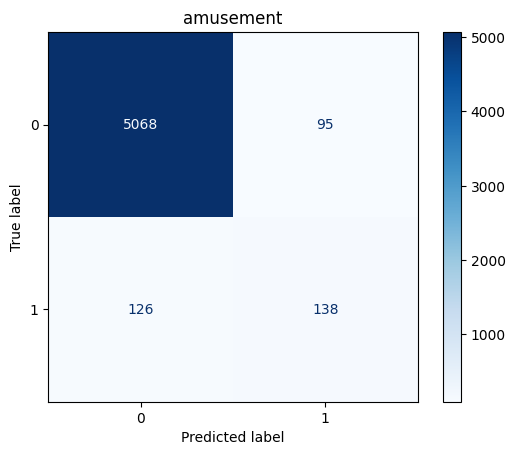

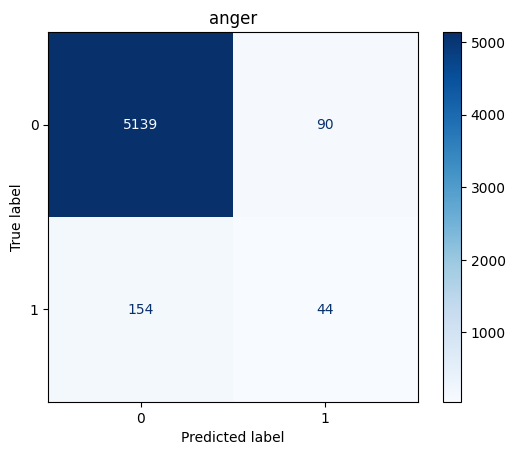

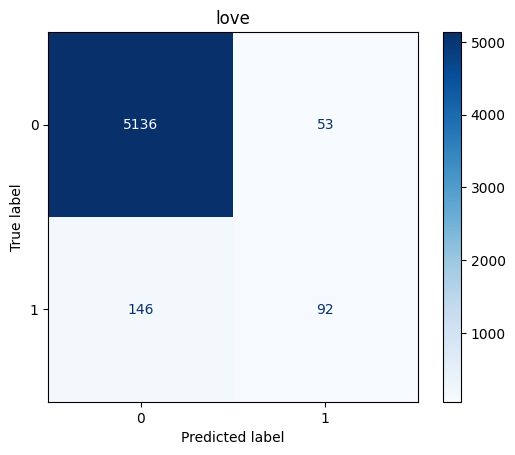

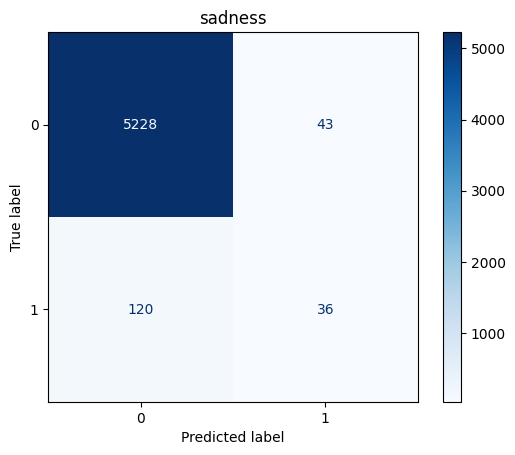

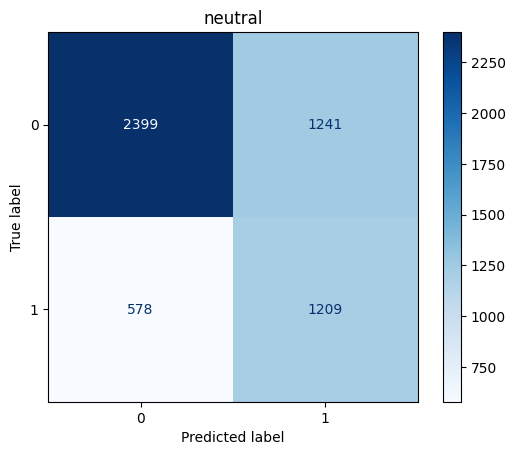

In [43]:
MulNB_sklearn_metrics = results_display(y_test, y_pred_test)

# Random Forest (Sklearn)

Fit and Validate

In [44]:
best_RF = None
best_f1 = -1
best_params = None

for depth in [5, 10, 15, 20, 25]:
    for tree in [25, 50, 75, 100]:
        print(f"Training with depth {depth}, tree count {tree}")
        model = RandomForestClassifier(n_estimators = tree, max_depth = depth, n_jobs = -1, random_state = 42)
        model.fit(X,y)
        y_pred_val = model.predict(X_val)
        f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
        if f1 > best_f1:
            best_RF = model
            best_f1 = f1
            best_params = (depth, tree)
        print(f"F1 score: {f1}")
print(f"Best RF: {best_RF}")
print(f"Best parameters: {best_params}")

Training with depth 5, tree count 25
F1 score: 0.016203232504172944
Training with depth 5, tree count 50
F1 score: 0.016203232504172944
Training with depth 5, tree count 75
F1 score: 0.016203232504172944
Training with depth 5, tree count 100
F1 score: 0.016203232504172944
Training with depth 10, tree count 25
F1 score: 0.016351612341981046
Training with depth 10, tree count 50
F1 score: 0.016351612341981046
Training with depth 10, tree count 75
F1 score: 0.016203232504172944
Training with depth 10, tree count 100
F1 score: 0.016351612341981046
Training with depth 15, tree count 25
F1 score: 0.020096078704581306
Training with depth 15, tree count 50
F1 score: 0.018278536662988957
Training with depth 15, tree count 75
F1 score: 0.01726760449198423
Training with depth 15, tree count 100
F1 score: 0.017703184860280257
Training with depth 20, tree count 25
F1 score: 0.027860077783991792
Training with depth 20, tree count 50
F1 score: 0.03176925784810828
Training with depth 20, tree count 75

Predict on test data

In [45]:
y_pred_test = best_RF.predict(X_test)

Results

Relaxed Accuracy: 0.37589828634604755
Relaxed F1 Score: 0.06318049896972044
F1 Score: 0.059447719594334085
                precision    recall  f1-score   support

    admiration       0.81      0.18      0.30       479
     amusement       0.83      0.25      0.39       245
         anger       0.00      0.00      0.00       190
     annoyance       0.00      0.00      0.00       262
      approval       0.00      0.00      0.00       292
        caring       0.00      0.00      0.00       110
     confusion       1.00      0.01      0.02       130
     curiosity       1.00      0.00      0.01       211
        desire       0.00      0.00      0.00        72
disappointment       0.00      0.00      0.00       116
   disapproval       0.00      0.00      0.00       211
       disgust       0.00      0.00      0.00        83
 embarrassment       0.00      0.00      0.00        28
    excitement       0.00      0.00      0.00        75
          fear       0.00      0.00      0.00       

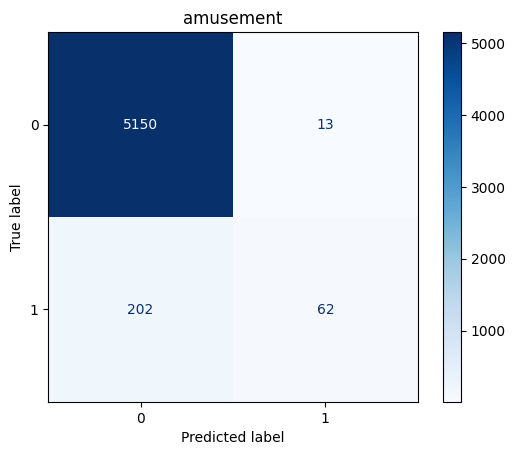

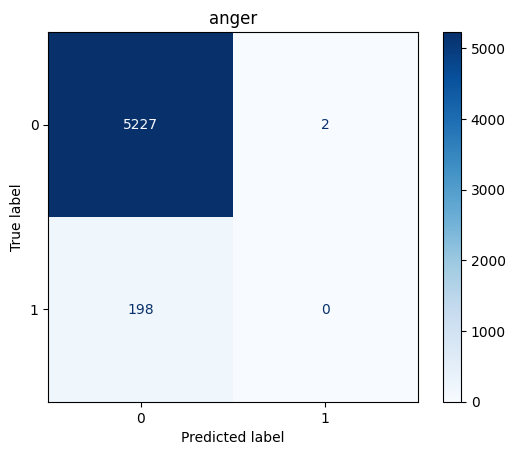

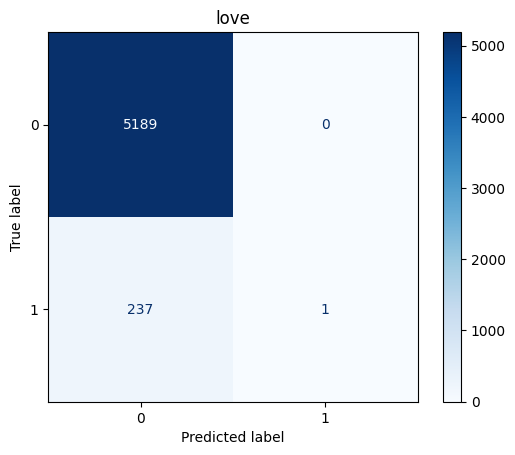

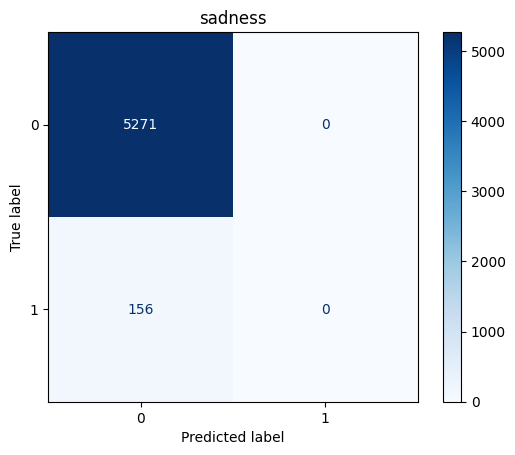

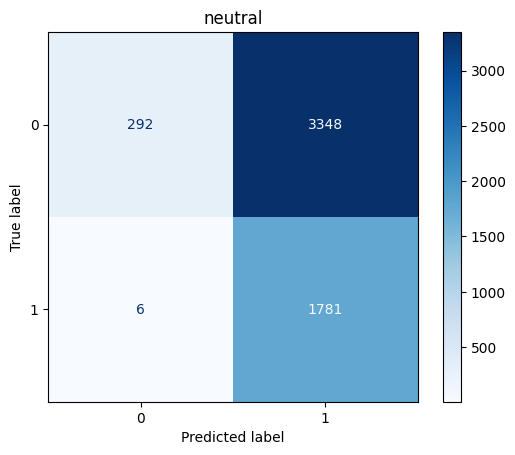

In [46]:
RF_sklearn_metrics = results_display(y_test, y_pred_test)

# Model comparison

In [47]:
comparison = {"Manual DT": DT_manual_metrics, "Sklearn DT": DT_sklearn_metrics, "Sklearn LogRes": LR_sklearn_metrics, "Sklearn Bernoulli NB": BerNB_sklearn_metrics, "Sklearn Multinomial NB": MulNB_sklearn_metrics, "Sklearn Random Forest": RF_sklearn_metrics}

In [48]:
comparison_df = pd.DataFrame(comparison).T
comparison_df

,Relaxed Accuracy,Relaxed Macro F1,Multilabel Macro F1
Manual DT,0.472821,0.206124,0.184752
Sklearn DT,0.512991,0.255892,0.226292
Sklearn LogRes,0.561636,0.393563,0.347779
Sklearn Bernoulli NB,0.459738,0.279583,0.249046
Sklearn Multinomial NB,0.461212,0.310365,0.273497
Sklearn Random Forest,0.375898,0.063180,0.059448


# Model outputs

In [ ]:
import joblib
joblib.dump(best_man_DT, "s_man_dt.pkl")
joblib.dump(best_sk_DT, "s_sk_dt.pkl")
joblib.dump(best_LR, "s_lr.pkl")
joblib.dump(best_Ber, "s_ber.pkl")
joblib.dump(best_Mul, "s_mul.pkl")
joblib.dump(best_RF, "s_rf.pkl")
joblib.dump(vocab, "vocab.pkl")

['s_rf.pkl']